# Stock Price Analysis & Monte Carlo Simulation
**Tools:** NumPy · Matplotlib · SciPy  
**Topics:** Returns analysis · Risk metrics · Monte Carlo 

---

## 1. Setup & Synthetic Data Generation
We simulate realistic OHLCV (Open, High, Low, Close, Volume) price data using **Geometric Brownian Motion (GBM)** — the same model behind the Black-Scholes formula.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Reproducibility
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.linewidth': 0.8,
    'font.family': 'monospace',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

In [ ]:
def generate_gbm_prices(S0, mu, sigma, days, dt=1/252):
    """
    Geometric Brownian Motion price simulator.
    
    Parameters
    S0    : float  - initial price
    mu    : float  - annual drift (expected return)
    sigma : float  - annual volatility
    days  : int    - number of trading days
    dt    : float  - time step (1/252 = 1 trading day)
    
    Returns
    np.ndarray of shape (days,)
    """
    Z = np.random.standard_normal(days)          # Wiener increments
    drift     = (mu - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt) * Z
    log_returns = drift + diffusion
    prices = S0 * np.exp(np.cumsum(log_returns))
    return np.concatenate([[S0], prices[:-1]])


# --- Simulate 3 stocks ---
DAYS = 252   # 1 trading year

stocks = {
    'AAPL': generate_gbm_prices(S0=180, mu=0.18, sigma=0.25, days=DAYS),
    'MSFT': generate_gbm_prices(S0=330, mu=0.22, sigma=0.22, days=DAYS),
    'TSLA': generate_gbm_prices(S0=240, mu=0.30, sigma=0.55, days=DAYS),
}

prices = np.column_stack(list(stocks.values()))  # shape: (252, 3)
tickers = list(stocks.keys())
days_axis = np.arange(DAYS)

print(f"Price matrix shape: {prices.shape}")
print(f"\nFinal prices:")
for t, p in zip(tickers, prices[-1]):
    print(f"  {t}: ${p:.2f}")

Price matrix shape: (252, 3)

Final prices:
  AAPL: $202.70
  MSFT: $434.66
  TSLA: $129.96


## 2. Price & Returns Visualization

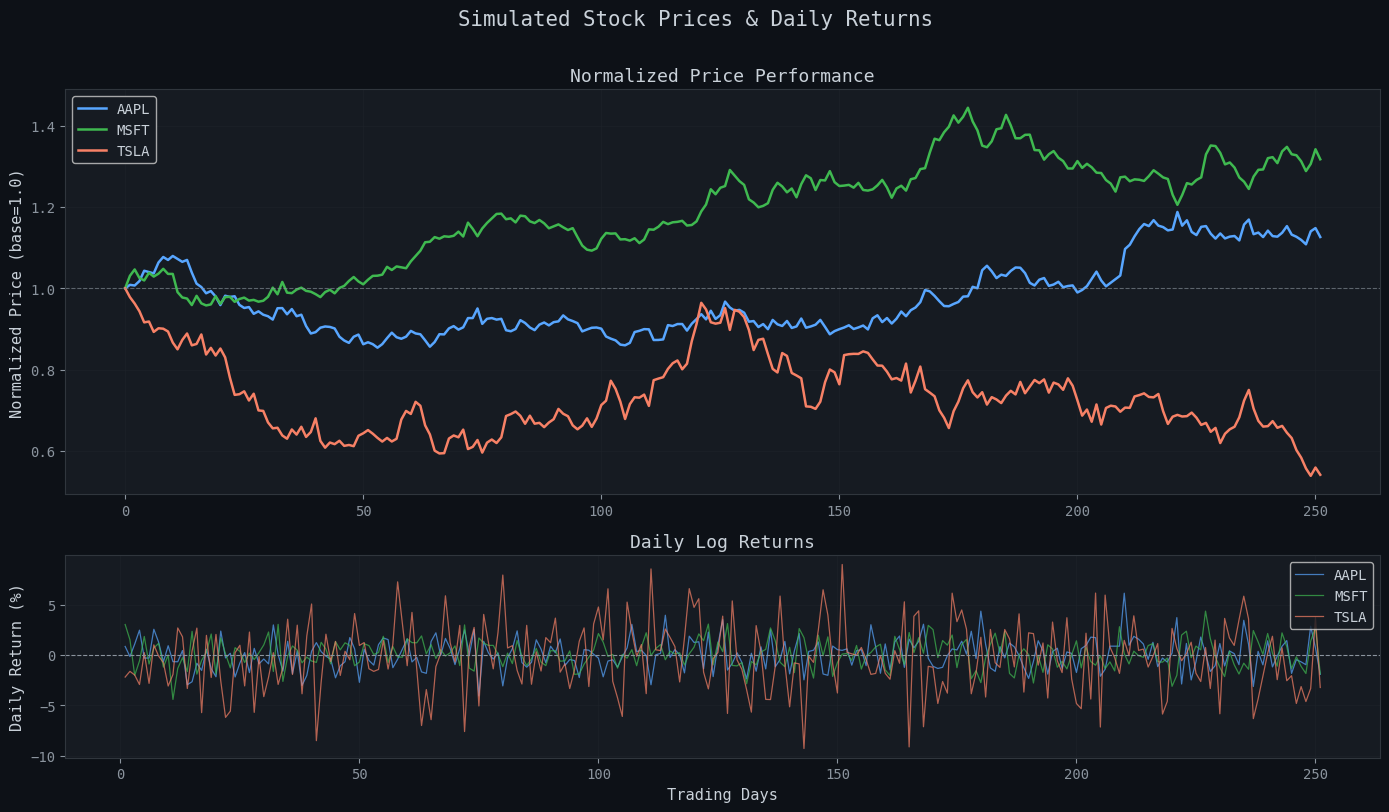

In [3]:
# Compute daily log returns
log_returns = np.diff(np.log(prices), axis=0)   # shape: (251, 3)

colors = ['#58a6ff', '#3fb950', '#f78166']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1])
fig.suptitle('Simulated Stock Prices & Daily Returns', fontsize=15, y=1.01)

# --- Top: Normalized prices ---
ax = axes[0]
norm_prices = prices / prices[0]   # base 1.0
for i, (t, c) in enumerate(zip(tickers, colors)):
    ax.plot(days_axis, norm_prices[:, i], label=t, color=c, linewidth=1.8)
ax.axhline(1.0, color='#8b949e', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_ylabel('Normalized Price (base=1.0)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
ax.set_title('Normalized Price Performance')

# --- Bottom: Daily returns ---
ax2 = axes[1]
for i, (t, c) in enumerate(zip(tickers, colors)):
    ax2.plot(days_axis[1:], log_returns[:, i] * 100,
             color=c, alpha=0.7, linewidth=0.9, label=t)
ax2.axhline(0, color='#8b949e', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Daily Return (%)')
ax2.set_xlabel('Trading Days')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.4)
ax2.set_title('Daily Log Returns')

plt.tight_layout()
plt.show()

## 3. Risk Metrics


In [4]:
def compute_risk_metrics(returns, ticker, confidence=0.95):
    """
    Computes annualized risk/return metrics for a return series.
    Returns a dict of metrics.
    """
    ann = 252
    
    mean_daily   = np.mean(returns)
    std_daily    = np.std(returns, ddof=1)
    
    ann_return   = mean_daily * ann
    ann_vol      = std_daily  * np.sqrt(ann)
    sharpe       = ann_return / ann_vol
    
    # Value at Risk (Historical)
    var_hist     = np.percentile(returns, (1 - confidence) * 100)
    
    # Conditional VaR (Expected Shortfall)
    cvar         = np.mean(returns[returns <= var_hist])
    
    # Max Drawdown
    cum_ret      = np.cumprod(1 + returns)
    running_max  = np.maximum.accumulate(cum_ret)
    drawdowns    = (cum_ret - running_max) / running_max
    max_dd       = np.min(drawdowns)
    
    # Skewness & Kurtosis (manual)
    skew = np.mean(((returns - mean_daily) / std_daily)**3)
    kurt = np.mean(((returns - mean_daily) / std_daily)**4) - 3  # excess
    
    return {
        'Ticker':          ticker,
        'Ann. Return':     f"{ann_return*100:+.2f}%",
        'Ann. Volatility': f"{ann_vol*100:.2f}%",
        'Sharpe Ratio':    f"{sharpe:.3f}",
        f'VaR ({int(confidence*100)}%)':  f"{var_hist*100:.3f}%",
        f'CVaR ({int(confidence*100)}%)': f"{cvar*100:.3f}%",
        'Max Drawdown':    f"{max_dd*100:.2f}%",
        'Skewness':        f"{skew:.3f}",
        'Excess Kurtosis': f"{kurt:.3f}",
    }


results = [compute_risk_metrics(log_returns[:, i], t) for i, t in enumerate(tickers)]

# Pretty print as table
keys = list(results[0].keys())
col_w = 20
header = ''.join(k.ljust(col_w) for k in keys)
print(header)
print('-' * len(header))
for r in results:
    print(''.join(str(v).ljust(col_w) for v in r.values()))

Ticker              Ann. Return         Ann. Volatility     Sharpe Ratio        VaR (95%)           CVaR (95%)          Max Drawdown        Skewness            Excess Kurtosis     
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
AAPL                +11.92%             24.18%              0.493               -2.298%             -2.856%             -21.27%             0.307               0.564               
MSFT                +27.66%             22.09%              1.252               -2.025%             -2.604%             -16.90%             0.065               -0.101              
TSLA                -61.58%             54.09%              -1.139              -5.822%             -7.119%             -52.36%             0.021               -0.142              


## 4. Correlation & Heatmap

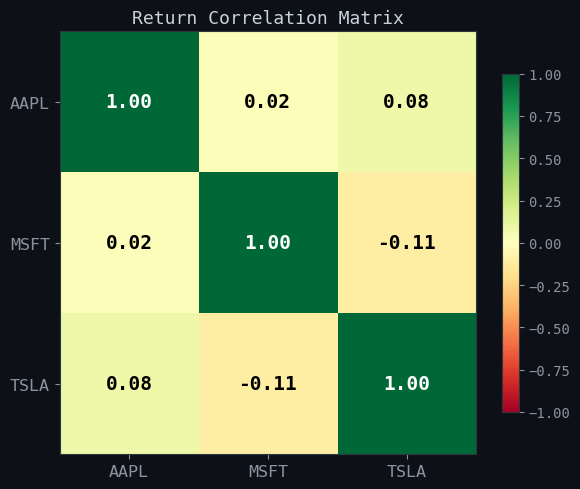

In [5]:
corr_matrix = np.corrcoef(log_returns.T)   # shape (3, 3)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers, fontsize=12)
ax.set_yticklabels(tickers, fontsize=12)
ax.set_title('Return Correlation Matrix', fontsize=13)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        val = corr_matrix[i, j]
        color = 'black' if abs(val) < 0.6 else 'white'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=14, color=color, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 5. Monte Carlo Simulation — Future Price Paths

We run **10,000 simulations** of the next 60 trading days for TSLA (highest volatility) using GBM parameters estimated from historical data.

In [6]:
def monte_carlo_simulation(last_price, mu_daily, sigma_daily, horizon, n_sims):
    """
    Vectorized Monte Carlo: returns matrix of shape (horizon, n_sims)
    """
    Z = np.random.standard_normal((horizon, n_sims))
    daily_returns = np.exp(
        (mu_daily - 0.5 * sigma_daily**2) + sigma_daily * Z
    )
    price_paths = last_price * np.cumprod(daily_returns, axis=0)
    return price_paths


# Use TSLA (index 2)
ticker_idx = 2
ticker_name = tickers[ticker_idx]
ret_series = log_returns[:, ticker_idx]

mu_est    = np.mean(ret_series)
sigma_est = np.std(ret_series, ddof=1)
S_last    = prices[-1, ticker_idx]

N_SIMS  = 10_000
HORIZON = 60   # trading days

paths = monte_carlo_simulation(S_last, mu_est, sigma_est, HORIZON, N_SIMS)
final_prices = paths[-1]

p5, p25, p50, p75, p95 = np.percentile(final_prices, [5, 25, 50, 75, 95])

print(f"Monte Carlo ({N_SIMS:,} simulations, {HORIZON}-day horizon) — {ticker_name}")
print(f"  Starting price : ${S_last:.2f}")
print(f"  5th  percentile: ${p5:.2f}")
print(f"  25th percentile: ${p25:.2f}")
print(f"  Median         : ${p50:.2f}")
print(f"  75th percentile: ${p75:.2f}")
print(f"  95th percentile: ${p95:.2f}")

Monte Carlo (10,000 simulations, 60-day horizon) — TSLA
  Starting price : $129.96
  5th  percentile: $70.07
  25th percentile: $90.45
  Median         : $108.18
  75th percentile: $128.64
  95th percentile: $166.92


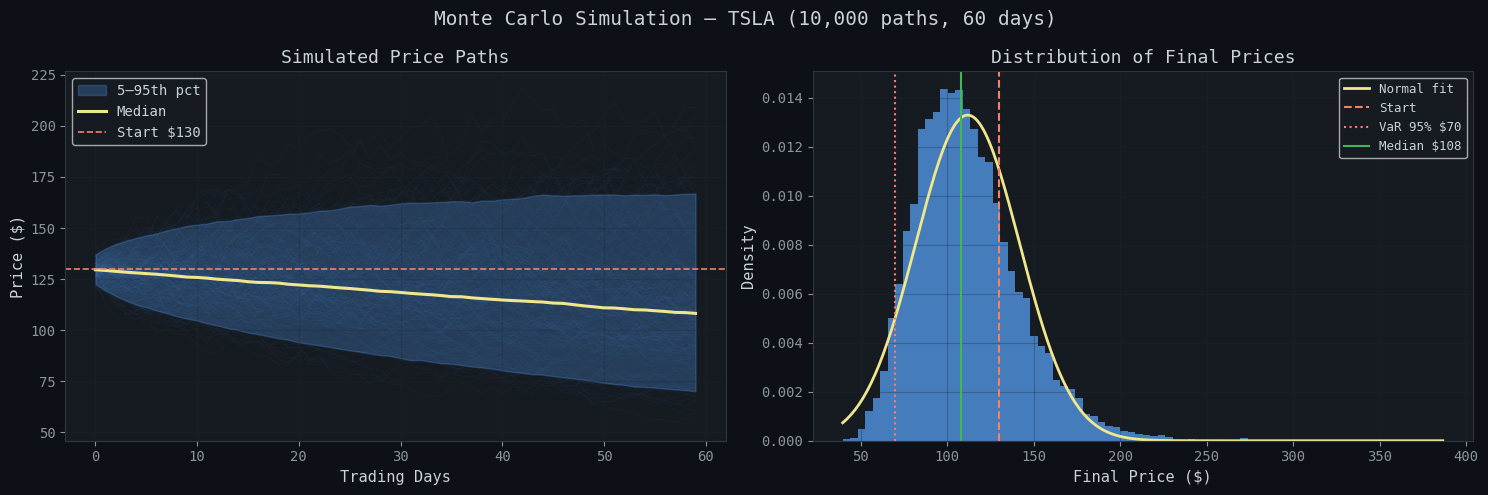

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Monte Carlo Simulation — {ticker_name} ({N_SIMS:,} paths, {HORIZON} days)', fontsize=14)

# --- Left: price fan chart ---
ax = axes[0]
t = np.arange(HORIZON)

# Plot 200 random paths
sample_idx = np.random.choice(N_SIMS, 200, replace=False)
for i in sample_idx:
    ax.plot(t, paths[:, i], color='#58a6ff', alpha=0.04, linewidth=0.6)

# Percentile bands
pct_lo = np.percentile(paths, 5,  axis=1)
pct_hi = np.percentile(paths, 95, axis=1)
pct_md = np.percentile(paths, 50, axis=1)

ax.fill_between(t, pct_lo, pct_hi, alpha=0.25, color='#58a6ff', label='5–95th pct')
ax.plot(t, pct_md, color='#f0e68c', linewidth=2.2, label='Median')
ax.axhline(S_last, color='#f78166', linestyle='--', linewidth=1.2, label=f'Start ${S_last:.0f}')

ax.set_xlabel('Trading Days')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title('Simulated Price Paths')

# --- Right: distribution of final prices ---
ax2 = axes[1]
n, bins, patches = ax2.hist(final_prices, bins=80, density=True,
                             color='#58a6ff', alpha=0.7, edgecolor='none')

# Overlay normal fit
mu_f, std_f = np.mean(final_prices), np.std(final_prices)
x_fit = np.linspace(final_prices.min(), final_prices.max(), 300)
ax2.plot(x_fit, stats.norm.pdf(x_fit, mu_f, std_f),
         color='#f0e68c', linewidth=2, label='Normal fit')

ax2.axvline(S_last, color='#f78166', linestyle='--', linewidth=1.5, label=f'Start')
ax2.axvline(p5,    color='#ff7b72',  linestyle=':',  linewidth=1.5, label=f'VaR 95% ${p5:.0f}')
ax2.axvline(p50,   color='#3fb950',  linestyle='-',  linewidth=1.5, label=f'Median ${p50:.0f}')

ax2.set_xlabel('Final Price ($)')
ax2.set_ylabel('Density')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_title('Distribution of Final Prices')

plt.tight_layout()
plt.show()

## 6. Portfolio Optimization — Efficient Frontier

We sample **50,000 random portfolios** and find the **maximum Sharpe ratio** and **minimum variance** portfolios using only NumPy.

In [8]:
N_PORTFOLIOS = 50_000
n_assets     = len(tickers)
ANN          = 252

# Annualized stats
mean_returns = np.mean(log_returns, axis=0) * ANN        # shape (3,)
cov_matrix   = np.cov(log_returns.T) * ANN               # shape (3, 3)

# Random weights — each row sums to 1
raw_weights  = np.random.dirichlet(np.ones(n_assets), size=N_PORTFOLIOS)  # (N, 3)

# Portfolio returns & volatility — vectorized
port_returns = raw_weights @ mean_returns                 # (N,)
port_vars    = np.einsum('ij,jk,ik->i', raw_weights, cov_matrix, raw_weights)  # (N,)
port_vols    = np.sqrt(port_vars)                         # (N,)
sharpe_ratios = port_returns / port_vols                  # (N,)

# Special portfolios
max_sharpe_idx = np.argmax(sharpe_ratios)
min_vol_idx    = np.argmin(port_vols)

print("Max Sharpe Portfolio:")
for t, w in zip(tickers, raw_weights[max_sharpe_idx]):
    print(f"  {t}: {w*100:.1f}%")
print(f"  Return={port_returns[max_sharpe_idx]*100:.2f}%  Vol={port_vols[max_sharpe_idx]*100:.2f}%  Sharpe={sharpe_ratios[max_sharpe_idx]:.3f}")

print("\nMin Volatility Portfolio:")
for t, w in zip(tickers, raw_weights[min_vol_idx]):
    print(f"  {t}: {w*100:.1f}%")
print(f"  Return={port_returns[min_vol_idx]*100:.2f}%  Vol={port_vols[min_vol_idx]*100:.2f}%  Sharpe={sharpe_ratios[min_vol_idx]:.3f}")

Max Sharpe Portfolio:
  AAPL: 27.8%
  MSFT: 72.2%
  TSLA: 0.0%
  Return=23.27%  Vol=17.43%  Sharpe=1.336

Min Volatility Portfolio:
  AAPL: 39.1%
  MSFT: 51.7%
  TSLA: 9.2%
  Return=13.32%  Vol=15.64%  Sharpe=0.852


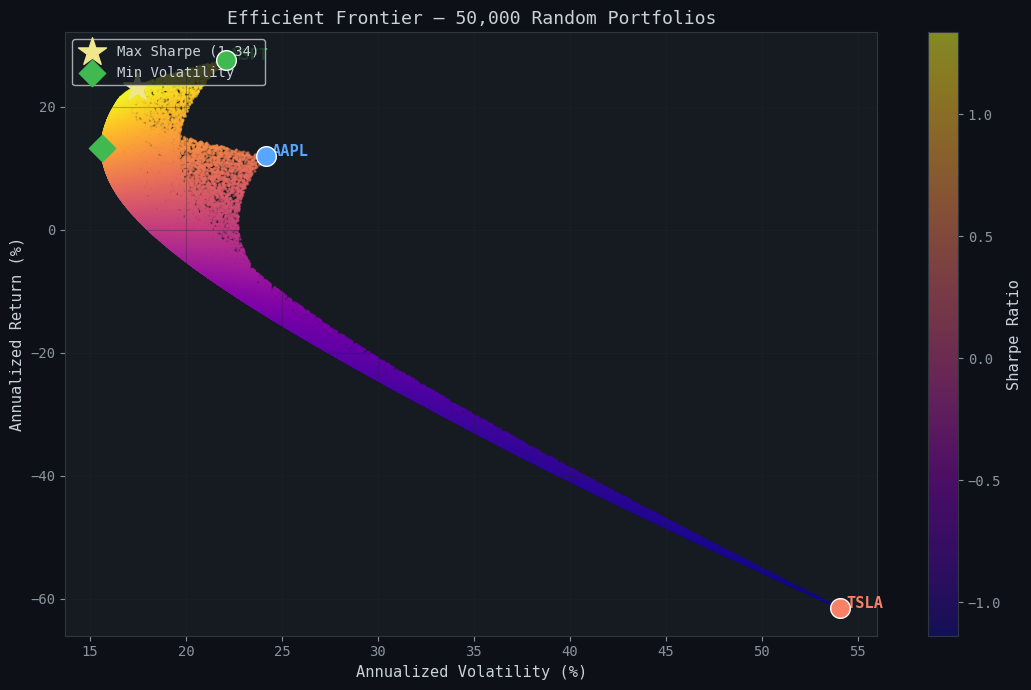

In [9]:
fig, ax = plt.subplots(figsize=(11, 7))

sc = ax.scatter(port_vols * 100, port_returns * 100,
                c=sharpe_ratios, cmap='plasma',
                s=1.5, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# Max Sharpe
ax.scatter(port_vols[max_sharpe_idx]*100, port_returns[max_sharpe_idx]*100,
           marker='*', s=450, color='#f0e68c', zorder=5,
           label=f'Max Sharpe ({sharpe_ratios[max_sharpe_idx]:.2f})')

# Min Vol
ax.scatter(port_vols[min_vol_idx]*100, port_returns[min_vol_idx]*100,
           marker='D', s=180, color='#3fb950', zorder=5,
           label=f'Min Volatility')

# Individual assets
asset_vols    = np.sqrt(np.diag(cov_matrix)) * 100
asset_returns = mean_returns * 100
for t, v, r, c in zip(tickers, asset_vols, asset_returns, colors):
    ax.scatter(v, r, s=200, color=c, zorder=6, edgecolors='white', linewidths=1)
    ax.annotate(t, (v + 0.3, r), fontsize=11, color=c, fontweight='bold')

ax.set_xlabel('Annualized Volatility (%)')
ax.set_ylabel('Annualized Return (%)')
ax.set_title(f'Efficient Frontier — {N_PORTFOLIOS:,} Random Portfolios', fontsize=13)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Return Distribution — Normality Test
Are log returns actually normally distributed? We check with the **Jarque-Bera test** and Q-Q plots.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Q-Q Plots: Log Returns vs Normal Distribution', fontsize=13)

for i, (t, ax, c) in enumerate(zip(tickers, axes, colors)):
    r = log_returns[:, i]
    
    # Q-Q via NumPy + SciPy
    (osm, osr), (slope, intercept, _) = stats.probplot(r)
    ax.plot(osm, osr, 'o', color=c, alpha=0.6, markersize=4)
    ax.plot(osm, slope * np.array(osm) + intercept, color='#f0e68c',
            linewidth=1.8, label='Normal line')
    
    # Jarque-Bera test
    jb_stat, jb_p = stats.jarque_bera(r)
    normal = "✓ Normal" if jb_p > 0.05 else "✗ Non-normal"
    ax.set_title(f'{t}  |  JB p={jb_p:.3f}  {normal}', fontsize=10)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Summary Dashboard

In [ ]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Portfolio Analysis Summary Dashboard', fontsize=16, y=1.01)

# 1 — Cumulative returns
ax1 = fig.add_subplot(gs[0, :])
for i, (t, c) in enumerate(zip(tickers, colors)):
    cum = np.cumprod(1 + log_returns[:, i]) - 1
    ax1.plot(days_axis[1:], cum * 100, color=c, label=t, linewidth=1.8)
ax1.axhline(0, color='#8b949e', linestyle='--', linewidth=0.8)
ax1.fill_between(days_axis[1:],
                 np.cumprod(1 + log_returns[:, 2]) * 100 - 100, 0,
                 alpha=0.05, color='#f78166')
ax1.set_ylabel('Cumulative Return (%)')
ax1.set_xlabel('Trading Day')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title('Cumulative Returns')

# 2 — Rolling 21-day volatility
ax2 = fig.add_subplot(gs[1, 0])
window = 21
for i, (t, c) in enumerate(zip(tickers, colors)):
    r = log_returns[:, i]
    roll_vol = np.array([
        np.std(r[max(0, j-window):j+1], ddof=1) * np.sqrt(252) * 100
        for j in range(len(r))
    ])
    ax2.plot(roll_vol, color=c, linewidth=1.2, label=t)
ax2.set_title('Rolling 21-day Volatility')
ax2.set_ylabel('Ann. Vol (%)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 3 — Return histogram
ax3 = fig.add_subplot(gs[1, 1])
for i, (t, c) in enumerate(zip(tickers, colors)):
    ax3.hist(log_returns[:, i] * 100, bins=30, alpha=0.55,
             color=c, label=t, density=True)
ax3.set_title('Return Distribution')
ax3.set_xlabel('Daily Return (%)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# 4 — Sharpe bar chart
ax4 = fig.add_subplot(gs[1, 2])
sharpes = [float(compute_risk_metrics(log_returns[:,i], t)['Sharpe Ratio']) for i,t in enumerate(tickers)]
bars = ax4.bar(tickers, sharpes, color=colors, edgecolor='#30363d', linewidth=1.2)
for bar, val in zip(bars, sharpes):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=11)
ax4.axhline(1.0, color='#f0e68c', linestyle='--', linewidth=1, label='Sharpe=1')
ax4.set_title('Sharpe Ratio by Asset')
ax4.set_ylabel('Sharpe Ratio')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

plt.savefig('/mnt/user-data/outputs/dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Dashboard saved ✓")

---
## Key Takeaways

| Concept | What we did |
|---|---|
| **GBM Simulation** | Generated realistic prices using Geometric Brownian Motion |
| **Risk Metrics** | Computed Sharpe, VaR, CVaR, Max Drawdown from scratch |
| **Monte Carlo** | 10,000 forward simulations with percentile fan charts |
| **Efficient Frontier** | 50,000 random portfolios, found max-Sharpe & min-vol |
| **Normality Testing** | Jarque-Bera test + Q-Q plots on return distributions |

All computation done with **NumPy** — no pandas, no QuantLib. 